<a href="https://colab.research.google.com/github/StoryChara/Noctua-Owls-Rivals-Analysis/blob/main/Analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Ranks de Jugadores

In [75]:
rank_columns = ['Rank 6', 'Rank 6.5', 'Rank 7', 'Rank 7.5', 'Rank Alto']
last_season = 'Rank 7.5'

# Código

Este notebook está diseñado para cargar, procesar y analizar datos de ranking de jugadores a lo largo de diferentes **seasons**. Proporciona funciones para transformar los datos, resumir la evolución del grupo y visualizar las tendencias individuales y colectivas.

## Configuraciones Basicas

Esta sección inicial configura el entorno y carga las librerías necesarias, además de definir mappings para los rangos que se utilizarán a lo largo del análisis.

In [76]:
import pandas as pd
from google.colab import drive, userdata
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import re
import numpy as np
import math

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
rank_map = {
    '2. Eternidad': 2,
    '3. Celestial': 3,
    '4. Gran Maestro': 4,
    '5. Diamante': 5,
    '6. Platino': 6,
    '7. Oro': 7,
    '8. Plata': 8,
    '9. Bronce': 9,
    '10. No Rank': 10
}

rank_label_map = {
    2: 'Eternidad',
    3: 'Celestial',
    4: 'Gran Maestro',
    5: 'Diamante',
    6: 'Platino',
    7: 'Oro',
    8: 'Plata',
    9: 'Bronce',
    10: 'No Rank'
}

La función `rank_to_num` convierte las representaciones de texto de los rangos a un valor numérico para facilitar los cálculos y comparaciones. Se asigna `NaN` para jugadores no presentes en el seguimiento y `10` para 'No Rank' (jugador presente pero sin rango asignado).

In [78]:
def rank_to_num(value):
    """
    Convierte strings tipo '3. Celestial' a número.
    Reglas:
    - NaN / vacío => NaN (ausencia en el seguimiento, NO peor rank)
    - 'N/A' => 10 (No Rank)
    """
    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    if value == '': return np.nan
    if value.upper() == 'N/A': return 10
    if value in rank_map: return rank_map[value]

    match = re.match(r'^(\d+(?:\.\d+)?)', value)
    if match:
        try:
            return int(float(match.group(1)))
        except:
            return np.nan

    return np.nan

Las siguientes funciones (`load_csv_file` y `prepare_csv_file`) se encargan de cargar el archivo de datos CSV desde la ruta especificada por el usuario y de realizar una limpieza y preprocesamiento inicial del DataFrame, incluyendo la creación de columnas numéricas para los rangos.

In [79]:
def load_csv_file():
    csv_file_path = userdata.get('file_path')

    try:
        df = pd.read_csv(csv_file_path, keep_default_na=False, na_values=[''])
    except FileNotFoundError:
        print(f"Error: The file was not found at {csv_file_path}. Please check the path and try again.")
        return None
    except Exception as e:
        print(f"An error occurred while loading the file: {e}")
        return None

    return df

def get_numerical_rank(rank_str):
    if pd.isna(rank_str) or rank_str == '':
        return pd.NA
    return rank_map.get(rank_str, 10) # Default to 10 if not found

def prepare_csv_file(df):
    if df is None:
        return None

    if 'Main Rol' in df.columns:
        df['Main Rol'] = df['Main Rol'].fillna('').str.split(',').apply( lambda x: [item.strip() for item in x if item.strip()] )

    df = df.drop(columns=[col for col in ['Perfil', 'Número'] if col in df.columns])

    if 'Plat.' in df.columns: df = df.rename(columns={'Plat.': 'Plataforma'})

    for col in rank_columns:
        if col in df.columns:
            # N/A = sí estaba en seguimiento pero sin rank
            df[col] = df[col].replace('N/A', '10. No Rank')

            # vacío / null se mantiene como NaN
            df[f'{col} Num'] = df[col].apply(rank_to_num)

    return df

Aquí se ejecuta el proceso de carga y preparación inicial del DataFrame utilizando las funciones definidas anteriormente.

In [80]:
df = load_csv_file()
df = prepare_csv_file(df)

if df is None: df = pd.DataFrame()

In [81]:
sns.set_theme(style="whitegrid")

## Analisis

Esta sección contiene las funciones principales para el análisis de los datos. Incluye la detección de columnas relevantes, la transformación del DataFrame a un formato largo para análisis longitudinal, el resumen de métricas por **season**, y el cálculo de transiciones y dinámicas de entrada/salida de jugadores.

La función `ensure_numeric_rank_columns` se asegura de que todas las columnas de rango identificadas tengan su contraparte numérica, aplicando la función `rank_to_num` para su conversión.

Esta función (`detect_rank_reference_columns`) identifica columnas de referencia para rangos, como el 'rank alto' o 'peak rank', si están presentes en el dataset.

Esta función (`detect_rank_sequence_columns`) identifica las columnas que representan la secuencia de rangos a lo largo del tiempo (ej. 'Rank 6', 'Rank 6.5', 'Rank 7').

Esta función (`detect_player_id_column`) identifica la columna que actúa como identificador único de cada jugador. Prioriza 'Nick' si existe, de lo contrario, usa la primera columna.

In [82]:
def detect_player_id_column(df):
    if 'Nick' in df.columns:
        return 'Nick'
    return df.columns[0]


def detect_rank_sequence_columns(df):
    seq_cols = []
    for col in df.columns:
        col_clean = str(col).strip()
        if re.fullmatch(r'Rank\s+\d+(?:\.\d+)?', col_clean, flags=re.IGNORECASE): seq_cols.append(col)

    def season_sort_key(col):
        num = re.search(r'(\d+(?:\.\d+)?)', str(col))
        return float(num.group(1)) if num else float('inf')

    seq_cols = sorted(seq_cols, key=season_sort_key)
    return seq_cols


def detect_rank_reference_columns(df):
    ref_candidates = {'rank alto', 'peak', 'rank peak', 'highest rank'}
    ref_cols = [col for col in df.columns if str(col).strip().lower() in ref_candidates]
    return ref_cols

def ensure_numeric_rank_columns(df, rank_cols):
    """
    Crea columnas '<Rank X> Num' si no existen o las recalcula si quieres consistencia.
    """
    for col in rank_cols:
        num_col = f'{col} Num'
        df[num_col] = df[col].apply(rank_to_num)
    return df


La función `overall_path_table` construye una tabla que resume la trayectoria general de cada jugador, mostrando su primer y último rango observado, y calculando la mejora neta en tiers.

La función `entries_and_exits` rastrea las incorporaciones y salidas de jugadores del seguimiento entre cortes consecutivos, identificando la dinámica de la composición del grupo.

La función `consecutive_transitions` analiza los cambios de rango entre cortes consecutivos. Calcula cuántos jugadores mejoraron, se mantuvieron o empeoraron, y la mejora promedio en tiers.

La función `summarize_by_cut` calcula métricas agregadas por cada corte, como el número de jugadores presentes, el promedio y la mediana del rank, y la distribución exacta de jugadores en cada tier competitivo.

La función `build_long_format` transforma el DataFrame de un formato 'ancho' a un formato 'largo', adecuado para análisis secuencial. Esto permite seguir la evolución de cada jugador a través de los diferentes cortes y calcula la 'Season' y 'Rank Label' para cada observación.

In [83]:
def build_long_format(df, player_col, seq_cols):
    """
    Pasa de formato ancho a largo para análisis secuencial.
    """
    num_cols = [f'{col} Num' for col in seq_cols]
    long_df = df[[player_col] + seq_cols + num_cols].copy()

    value_df = long_df.melt(
        id_vars=[player_col],
        value_vars=seq_cols,
        var_name='Season Label',
        value_name='Rank Texto'
    )

    num_df = long_df.melt(
        id_vars=[player_col],
        value_vars=num_cols,
        var_name='Season Num Col',
        value_name='Rank Num'
    )

    num_df['Season Label'] = num_df['Season Num Col'].str.replace(' Num', '', regex=False)

    merged_df = value_df.merge(
        num_df[[player_col, 'Season Label', 'Rank Num']],
        on=[player_col, 'Season Label'],
        how='left'
    )

    merged_df['Presente en Seguimiento'] = merged_df['Rank Num'].notna()
    merged_df['Season'] = merged_df['Season Label'].str.extract(r'(\d+(?:\.\d+)?)').astype(float)
    merged_df['Rank Label'] = merged_df['Rank Num'].map(rank_label_map)

    return merged_df.sort_values(['Season', player_col]).reset_index(drop=True)

def summarize_by_cut(long_df):
    """
    Resume métricas por corte, considerando solo jugadores presentes en seguimiento.
    Cada rango se cuenta de forma exacta, no acumulada.
    """
    present = long_df[long_df['Presente en Seguimiento']].copy()

    # Explicitly drop the numerical 'Season' column if it exists,
    # as we only want 'Season Label' for grouping and then rename it.
    if 'Season' in present.columns:
        present = present.drop(columns=['Season'])

    # Group by 'Season Label' only
    summary = present.groupby('Season Label').agg(
        jugadores_presentes=('Rank Num', 'size'),
        promedio_rank=('Rank Num', 'mean'),
        mediana_rank=('Rank Num', 'median'),
        eternidad=('Rank Num', lambda s: (s == 2).sum()),
        celestial=('Rank Num', lambda s: (s == 3).sum()),
        gran_maestro=('Rank Num', lambda s: (s == 4).sum()),
        diamante=('Rank Num', lambda s: (s == 5).sum()),
        platino=('Rank Num', lambda s: (s == 6).sum()),
        oro=('Rank Num', lambda s: (s == 7).sum()),
        plata=('Rank Num', lambda s: (s == 8).sum()),
        bronce=('Rank Num', lambda s: (s == 9).sum()),
        no_rank=('Rank Num', lambda s: (s == 10).sum())
    ).reset_index() # Now, only 'Season Label' is a column from the groupby

    # Extract numerical season for sorting
    summary['_temp_season_num'] = summary['Season Label'].str.extract(r'(\d+(?:\.\d+)?)').astype(float)
    summary = summary.sort_values('_temp_season_num')
    summary = summary.drop(columns=['_temp_season_num']) # Drop the temporary column

    # Preserve numerical values for calculations, renaming them to avoid conflict with display columns
    summary['Promedio Rank Num'] = summary['promedio_rank'].round(2)
    summary['Mediana Rank Num'] = summary['mediana_rank'].round().astype(int)

    # Helper to convert numerical rank to label
    def num_to_rank_label(num):
        if pd.isna(num):
            return np.nan
        # Ensure that the number is within the keys of rank_label_map or handle it
        if int(num) in rank_label_map:
            return rank_label_map.get(int(num))
        # Handle cases where rounded rank might be out of range, e.g., 1 or 11
        elif num <= 2: return 'Eternidad' # Treat anything below 2 as Eternidad
        elif num >= 10: return 'No Rank' # Treat anything above 10 as No Rank
        return 'Desconocido' # Fallback for unexpected values


    # Convert 'Promedio Rank Num' to text format for display
    summary['Promedio Rank Display'] = summary['Promedio Rank Num'].apply(
        lambda x: f"{num_to_rank_label(math.ceil(x))} - {num_to_rank_label(math.floor(x))}" if pd.notna(x) else np.nan
    )
    # Convert 'Mediana Rank Num' to text format for display
    summary['Mediana Rank Display'] = summary['Mediana Rank Num'].apply(num_to_rank_label)

    # Rename 'Season Label' to 'Season' and other columns
    summary = summary.rename(columns={
        'Season Label': 'Season',
        'jugadores_presentes': 'Jugadores Presentes',
        'eternidad': 'Eternidad',
        'celestial': 'Celestial',
        'gran_maestro': 'Gran Maestro',
        'diamante': 'Diamante',
        'platino': 'Platino',
        'oro': 'Oro',
        'plata': 'Plata',
        'bronce': 'Bronce',
        'no_rank': 'No Rank'
    })

    # Select and reorder columns, including the new numerical columns and display columns
    summary = summary[['Season', 'Jugadores Presentes',
                       'Promedio Rank Display', 'Mediana Rank Display',
                       'Promedio Rank Num', 'Mediana Rank Num', # Keep numerical for calculation
                       'Eternidad', 'Celestial', 'Gran Maestro', 'Diamante',
                       'Platino', 'Oro', 'Plata', 'Bronce', 'No Rank']]

    # Rename display columns to their final names
    summary = summary.rename(columns={
        'Promedio Rank Display': 'Promedio Rank',
        'Mediana Rank Display': 'Mediana Rank'
    })

    return summary


def consecutive_transitions(df, player_col, seq_cols):
    transitions = []
    detail_tables = {}

    # Helper to convert numerical rank to label (reusing from summarize_by_cut)
    def num_to_rank_label(num):
        if pd.isna(num):
            return np.nan
        if int(num) in rank_label_map:
            return rank_label_map.get(int(num))
        elif num <= 2: return 'Eternidad'
        elif num >= 10: return 'No Rank'
        return 'Desconocido'

    for prev_col, curr_col in zip(seq_cols[:-1], seq_cols[1:]):
        prev_num = f'{prev_col} Num'
        curr_num = f'{curr_col} Num'

        temp = df[[player_col, prev_col, curr_col, prev_num, curr_num]].copy()
        both = temp[temp[prev_num].notna() & temp[curr_num].notna()].copy()

        if both.empty:
            continue

        both['delta'] = both[prev_num] - both[curr_num]  # positivo = mejora
        both['estado_cambio'] = np.select(
            [both[curr_num] < both[prev_num], both[curr_num] == both[prev_num], both[curr_num] > both[prev_num]],
            ['Mejoró', 'Se mantuvo', 'Empeoró'],
            default='Sin dato'
        )

        # Calculate averages
        avg_initial_rank = round(both[prev_num].mean(), 2)
        avg_final_rank = round(both[curr_num].mean(), 2)

        summary = {
            'transicion': f"Season {re.search(r'(\d+(?:\.\d+)?)', prev_col).group(0)} → Season {re.search(r'(\d+(?:\.\d+)?)', curr_col).group(0)}",
            'comparables': len(both),
            'mejoraron': int((both['estado_cambio'] == 'Mejoró').sum()),
            'se_mantuvieron': int((both['estado_cambio'] == 'Se mantuvo').sum()),
            'empeoraron': int((both['estado_cambio'] == 'Empeoró').sum()),
            'mejora_promedio_tiers': round(both['delta'].mean(), 2),
            'promedio_inicial': avg_initial_rank,
            'promedio_final': avg_final_rank,
            'Promedio Inicial Rank': f"{num_to_rank_label(math.ceil(avg_initial_rank))} - {num_to_rank_label(math.floor(avg_initial_rank))}",
            'Promedio Final Rank': f"{num_to_rank_label(math.ceil(avg_final_rank))} - {num_to_rank_label(math.floor(avg_final_rank))}"
        }
        transitions.append(summary)

        detail_tables[f"Season {re.search(r'(\d+(?:\.\d+)?)', prev_col).group(0)} → Season {re.search(r'(\d+(?:\.\d+)?)', curr_col).group(0)} "] = both.sort_values(
            by=['delta', player_col], ascending=[False, True]
        )

    transitions_df = pd.DataFrame(transitions)

    # Rename columns to Capital Case and user-specified names
    transitions_df = transitions_df.rename(columns={
        'transicion': 'Transición',
        'comparables': 'Jugadores Comparables',
        'mejoraron': 'Mejoraron',
        'se_mantuvieron': 'Sin Cambio',
        'empeoraron': 'Empeoraron',
        'mejora_promedio_tiers': 'Mejora Promedio',
        'promedio_inicial': 'Promedio Inicial Num',
        'promedio_final': 'Promedio Final Num',
        'Promedio Inicial Rank': 'Promedio Inicial',
        'Promedio Final Rank': 'Promedio Final'
    })

    # Reorder and select columns, dropping the numerical averages
    transitions_df = transitions_df[[
        'Transición', 'Jugadores Comparables', 'Mejoraron', 'Sin Cambio', 'Empeoraron',
        'Mejora Promedio', 'Promedio Inicial', 'Promedio Final'
    ]]

    return transitions_df, detail_tables


def entries_and_exits(df, player_col, seq_cols):
    rows = []

    for prev_col, curr_col in zip(seq_cols[:-1], seq_cols[1:]):
        prev_num = f'{prev_col} Num'
        curr_num = f'{curr_col} Num'

        prev_present = df[prev_num].notna()
        curr_present = df[curr_num].notna()

        incorporaciones = int((~prev_present & curr_present).sum())
        salidas = int((prev_present & ~curr_present).sum())
        estables = int((prev_present & curr_present).sum())

        rows.append({
            'transicion': f"Season {re.search(r'(\d+(?:\.\d+)?)', prev_col).group(0)} → Season {re.search(r'(\d+(?:\.\d+)?)', curr_col).group(0)}",
            'incorporaciones_seguimiento': incorporaciones,
            'salidas_seguimiento': salidas,
            'presentes_ambos': estables
        })

    entries_df = pd.DataFrame(rows)
    entries_df = entries_df.rename(columns={
        'transicion': 'Transición',
        'incorporaciones_seguimiento': 'Nuevos',
        'salidas_seguimiento': 'Salidas',
        'presentes_ambos': 'Continuos'
    })
    return entries_df


def overall_path_table(df, player_col, seq_cols):
    rows = []

    for _, row in df.iterrows():
        observations = []
        for col in seq_cols:
            num_val = row.get(f'{col} Num', np.nan)
            if pd.notna(num_val):
                # Corrected regex pattern here
                season_val = float(re.search(r'(\d+(?:\.\d+)?)', col).group(1))
                observations.append((col, season_val, num_val, row.get(col, np.nan)))

        if not observations: continue

        observations = sorted(observations, key=lambda x: x[1])
        first_col, _, first_num, first_text = observations[0]
        last_col, _, last_num, last_text = observations[-1]

        rows.append({
            player_col: row[player_col],
            'Primer Season': first_col,
            'Última Season': last_col,
            'rank_inicial_texto': first_text,
            'rank_final_texto': last_text,
            'rank_inicial_num': first_num,
            'rank_final_num': last_num,
            'mejora_neta': first_num - last_num,
            'cortes_observados': len(observations)
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        # Filter by last_season
        out = out[out['Última Season'] == last_season]

        # Rename columns
        out = out.rename(columns={
            'rank_inicial_texto': 'Rank Inicial',
            'rank_final_texto': 'Rank Final',
            'cortes_observados': 'Número de Seasons',
            'mejora_neta': 'Mejora Neta'
        })

        # Drop numerical rank columns
        out = out.drop(columns=['rank_inicial_num', 'rank_final_num'])

        out = out.sort_values(['Mejora Neta', 'Número de Seasons', player_col], ascending=[False, False, True])
    return out

La función `executive_summary_md` genera un resumen ejecutivo en formato Markdown, consolidando las principales métricas y tendencias del análisis para una fácil comprensión.

In [84]:
def executive_summary_md(cut_summary, transitions_df, entries_df):
    if cut_summary.empty:
        return "## Resumen ejecutivo\n\nNo hay suficientes datos para generar el resumen."

    first_cut = cut_summary.iloc[0]
    last_cut = cut_summary.iloc[-1]

    # Ensure these refer to the 'Season' column, not 'Season Label'
    first_season_label = first_cut['Season']
    last_season_label = last_cut['Season']

    # Use the numerical rank columns for calculation
    avg_change = round(first_cut['Promedio Rank Num'] - last_cut['Promedio Rank Num'], 2)

    low_first = int(first_cut['Oro'] + first_cut['Plata'] + first_cut['Bronce'])
    low_last = int(last_cut['Oro'] + last_cut['Plata'] + last_cut['Bronce'])

    plat_first = int(first_cut['Platino'])
    plat_last = int(last_cut['Platino'])

    dia_first = int(first_cut['Diamante'])
    dia_last = int(last_cut['Diamante'])

    gm_first = int(first_cut['Gran Maestro'])
    gm_last = int(last_cut['Gran Maestro'])

    cel_first = int(first_cut['Celestial'])
    cel_last = int(last_cut['Celestial'])

    ete_first = int(first_cut['Eternidad'])
    ete_last = int(last_cut['Eternidad'])

    if avg_change > 0:
        tendencia = f"El promedio del grupo **mejoró {avg_change} tiers** entre **{first_season_label}** y **{last_season_label}**."
    elif avg_change < 0:
        tendencia = f"El promedio del grupo **empeoró {abs(avg_change)} tiers** entre **{first_season_label}** y **{last_season_label}**."
    else:
        tendencia = f"El promedio del grupo **se mantuvo estable** entre **{first_season_label}** y **{last_season_label}**."

    transicion_md = ""
    if not transitions_df.empty:
        total_improved = int(transitions_df['Mejoraron'].sum()) # Corrected column name
        total_same = int(transitions_df['Sin Cambio'].sum())    # Corrected column name
        total_worse = int(transitions_df['Empeoraron'].sum())   # Corrected column name

        transicion_md = f"""
### Cambios entre seasons consecutivas

- **Mejoras acumuladas:** {total_improved}
- **Mantenimientos acumulados:** {total_same}
- **Retrocesos acumulados:** {total_worse}
"""

    entradas_md = ""
    if not entries_df.empty:
        total_entries = int(entries_df['Nuevos'].sum()) # Corrected column name
        total_exits = int(entries_df['Salidas'].sum())   # Corrected column name

        entradas_md = f"""
### Dinámica del seguimiento

- **Incorporaciones al seguimiento:** {total_entries}
- **Salidas del seguimiento:** {total_exits}

> Los valores nulos en los ranks representan **ausencia en el seguimiento del grupo en esa season**, no ausencia de rango competitivo dentro del juego.
"""

    informe = f"""
## Resumen ejecutivo

El seguimiento cubre desde **{first_season_label}** hasta **{last_season_label}**.

### Tendencia general

- {tendencia}
- El promedio del grupo pasó de **{first_cut['Promedio Rank']}** a **{last_cut['Promedio Rank']}**.
- La mediana del grupo pasó de **{first_cut['Mediana Rank']}** a **{last_cut['Mediana Rank']}**.

### Composición competitiva exacta del grupo

- **Eternidad:** **{ete_first} → {ete_last}**
- **Celestial:** **{cel_first} → {cel_last}**
- **Gran Maestro:** **{gm_first} → {gm_last}**
- **Diamante:** **{dia_first} → {dia_last}**
- **Platino:** **{plat_first} → {plat_last}**
- **Oro:** **{int(first_cut['Oro'])} → {int(last_cut['Oro'])}**
- **Plata:** **{int(first_cut['Plata'])} → {int(last_cut['Plata'])}**
- **Bronce:** **{int(first_cut['Bronce'])} → {int(last_cut['Bronce'])}**
- **No Rank:** **{int(first_cut['No Rank'])} → {int(last_cut['No Rank'])}**

### Lectura agregada

- Jugadores en **Oro/Plata/Bronce**: **{low_first} → {low_last}**

{transicion_md}

{entradas_md}
"""
    return informe

## Funciones de Visualización

Esta sección contiene funciones que encapsulan la lógica para generar los diferentes gráficos. Esto ayuda a mantener el código organizado y las celdas de visualización más limpias.

In [85]:
def plot_avg_median_rank(cut_summary, rank_label_map):
    """
    Genera un gráfico de línea mostrando la evolución del promedio y la mediana
    de los rangos del grupo a lo largo de las seasons.
    """
    if not cut_summary.empty:
        plt.figure(figsize=(10, 5))
        plt.plot(cut_summary['Season'], cut_summary['Promedio Rank Num'], marker='o', label='Promedio')
        plt.plot(cut_summary['Season'], cut_summary['Mediana Rank Num'], marker='s', label='Mediana')

        plt.gca().invert_yaxis()

        min_rank_val = min(cut_summary['Promedio Rank Num'].min(), cut_summary['Mediana Rank Num'].min())
        max_rank_val = max(cut_summary['Promedio Rank Num'].max(), cut_summary['Mediana Rank Num'].max())

        rank_nums_for_ticks = sorted([k for k in rank_label_map.keys() if k >= math.floor(min_rank_val) and k <= math.ceil(max_rank_val)])
        rank_labels_for_ticks = [rank_label_map[num] for num in rank_nums_for_ticks]

        plt.yticks(rank_nums_for_ticks, rank_labels_for_ticks)

        plt.title('Evolución del nivel del grupo por season')
        plt.ylabel('Rank')
        plt.xlabel('Season')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos en el resumen por corte para graficar la evolución del nivel.")

def plot_rank_distribution(long_df, player_col, rank_label_map, rank_sequence_columns):
    """
    Genera un gráfico de barras apiladas mostrando la distribución de jugadores
    por rango por season.
    """
    dist_df = long_df[long_df['Presente en Seguimiento']].copy()
    if not dist_df.empty:
        if 'Season Label' not in dist_df.columns and 'Corte' in dist_df.columns:
            dist_df = dist_df.rename(columns={'Corte': 'Season Label'})

        dist_table = dist_df.pivot_table(
            index='Season Label',
            columns='Rank Label',
            values=player_col,
            aggfunc='count',
            fill_value=0
        )

        dist_table = dist_table.reindex(rank_sequence_columns)

        ordered_labels = [rank_label_map[k] for k in sorted(rank_label_map.keys()) if rank_label_map[k] in dist_table.columns]
        dist_table = dist_table.reindex(columns=ordered_labels)

        dist_table.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
        plt.title('Distribución de ranks por season')
        plt.xlabel('Season')
        plt.ylabel('Cantidad de jugadores')
        plt.legend(title='Rank', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos de distribución de ranks para graficar.")

def plot_transitions(transitions_df):
    """
    Genera un gráfico de barras comparando el número de jugadores que mejoraron,
    se mantuvieron o empeoraron su rango entre seasons consecutivas.
    """
    if not transitions_df.empty:
        trans_plot = transitions_df.melt(
            id_vars='Transición',
            value_vars=['Mejoraron', 'Sin Cambio', 'Empeoraron'],
            var_name='estado',
            value_name='cantidad'
        )
        plt.figure(figsize=(11, 5))
        sns.barplot(data=trans_plot, x='Transición', y='cantidad', hue='estado')
        plt.title('Cambios entre seasons consecutivas')
        plt.xlabel('Transición')
        plt.ylabel('Cantidad de jugadores')
        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos de transiciones para graficar.")

def plot_entries_exits(entries_df):
    """
    Genera un gráfico de barras visualizando las incorporaciones y salidas de jugadores
    del seguimiento en cada season.
    """
    if not entries_df.empty:
        entries_plot = entries_df.melt(
            id_vars='Transición',
            value_vars=['Nuevos', 'Salidas', 'Continuos'], # Changed from 'Presentes en Ambas Seasons'
            var_name='tipo',
            value_name='cantidad'
        )
        plt.figure(figsize=(11, 5))
        sns.barplot(data=entries_plot, x='Transición', y='cantidad', hue='tipo', palette='viridis')
        plt.title('Dinámica del seguimiento: incorporaciones, salidas y permanencia')
        plt.xlabel('Transición')
        plt.ylabel('Cantidad de jugadores')
        plt.legend(title='Tipo de Jugador')
        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos de incorporaciones y salidas para graficar.")

def plot_slope_chart(long_df, path_df, player_col, rank_label_map, last_season):
    """
    Genera un 'slope chart' mostrando la trayectoria individual de los rangos de los jugadores.
    """
    if not long_df.empty:
        multi_obs = long_df[long_df['Presente en Seguimiento']].groupby(player_col).size()
        multi_obs_players = multi_obs[multi_obs >= 2].index

        players_in_last_season_from_path = path_df[player_col].unique()

        slope_df = long_df[
            long_df[player_col].isin(multi_obs_players) &
            long_df[player_col].isin(players_in_last_season_from_path) &
            long_df['Presente en Seguimiento']
        ].copy()

        if not slope_df.empty:
            plt.figure(figsize=(12, 7))

            for name, sub in slope_df.groupby(player_col):
                sub = sub.sort_values('Season')
                plt.plot(sub['Season'], sub['Rank Num'], marker='o', alpha=0.35, label=name)

            plt.gca().invert_yaxis()

            min_season = slope_df['Season'].min()
            max_season = slope_df['Season'].max()
            xticks = np.arange(min_season, max_season + 0.5, 0.5)
            plt.xticks(xticks, [str(x).rstrip('0').rstrip('.') for x in xticks])

            min_rank_val = slope_df['Rank Num'].min()
            max_rank_val = slope_df['Rank Num'].max()

            rank_nums_for_ticks = sorted(list(set([int(k) for k in rank_label_map.keys() if k >= math.floor(min_rank_val) and k <= math.ceil(max_rank_val)])))
            rank_labels_for_ticks = [rank_label_map[num] for num in rank_nums_for_ticks]
            plt.yticks(rank_nums_for_ticks, rank_labels_for_ticks)

            plt.title('Trayectoria individual de jugadores a lo largo de las seasons')
            plt.xlabel('Season')
            plt.ylabel('Rank')
            plt.legend(loc='lower right', fontsize='small', ncol=3)
            plt.tight_layout()
            plt.show()
        else:
            print("No hay suficientes datos en el slope_df para graficar.")
    else:
        print("No hay datos en long_df para graficar el slope chart.")

Esta sección es el corazón del análisis. Aquí se utilizan las funciones previamente definidas para procesar los datos, detectar columnas, transformar el DataFrame, y calcular los resúmenes clave como `cut_summary`, `transitions_df`, `entries_df`, y `path_df`.

In [86]:
player_col = detect_player_id_column(df)
rank_sequence_columns = detect_rank_sequence_columns(df)
rank_reference_columns = detect_rank_reference_columns(df)

# -------------------------
# 3) Crear columnas numéricas de forma escalable
# -------------------------'
all_rank_cols = rank_sequence_columns + rank_reference_columns
df = ensure_numeric_rank_columns(df, all_rank_cols);

# -------------------------
# 4) Longitudinal: formato largo y resumen por season
# -------------------------'
long_df = build_long_format(df, player_col, rank_sequence_columns)
cut_summary = summarize_by_cut(long_df)

# Replace 'Rank' with 'Season' in 'Season' column for cut_summary
if not cut_summary.empty:
    cut_summary['Season'] = cut_summary['Season'].str.replace('Rank', 'Season')

# -------------------------
# 5) Transiciones consecutivas y dinámica de seguimiento
# -------------------------'
transitions_df, transition_details = consecutive_transitions(df, player_col, rank_sequence_columns)
entries_df = entries_and_exits(df, player_col, rank_sequence_columns)
path_df = overall_path_table(df, player_col, rank_sequence_columns)

# Replace 'Rank' with 'Season' in 'Primer Season' and 'Última Season' for display
if not path_df.empty:
    path_df['Primer Season'] = path_df['Primer Season'].str.replace('Rank', 'Season')
    path_df['Última Season'] = path_df['Última Season'].str.replace('Rank', 'Season')

# -------------------------
# 6) Estabilidad en alto rango (Diamante o superior en todos sus cortes observados)
# -------------------------'
# Helper function for rank labels - copied to ensure it's available in this cell's scope
def num_to_rank_label(num):
    if pd.isna(num):
        return np.nan
    if int(num) in rank_label_map:
        return rank_label_map.get(int(num))
    elif num <= 2: return 'Eternidad'
    elif num >= 10: return 'No Rank'
    return 'Desconocido'

# Only proceed if long_df and path_df are not empty
if not long_df.empty and not path_df.empty:
    # Filter long_df to only include players that have 'Última Season' as `last_season`
    players_in_last_season_path = path_df[path_df['Última Season'] == last_season.replace('Rank', 'Season')][player_col].unique()
    filtered_long_df = long_df[long_df[player_col].isin(players_in_last_season_path)]

    stable_high_data = filtered_long_df[filtered_long_df['Presente en Seguimiento']].groupby(player_col).agg(
        MinRankNum=('Rank Num', 'min'),
        MaxRankNum=('Rank Num', 'max'),
        Seasons=('Rank Num', 'size')
    ).reset_index()

    # Filter for high ranks (MaxRankNum <= 5 means Diamante or higher) and at least 2 seasons
    stable_high_data = stable_high_data[(stable_high_data['MaxRankNum'] <= 5) & (stable_high_data['Seasons'] >= 2)]

    if not stable_high_data.empty:
        # Create rank label columns
        stable_high_data['Mejor Rank'] = stable_high_data['MinRankNum'].apply(num_to_rank_label)
        stable_high_data['Peor Rank'] = stable_high_data['MaxRankNum'].apply(num_to_rank_label)

        # Rename player_col
        stable_high_data = stable_high_data.rename(columns={player_col: 'Jugador'})

        # Sort by MaxRankNum (numerical for correct rank order), then Seasons (descending), then Jugador (ascending)
        stable_high_display = stable_high_data.sort_values(
            ['MaxRankNum', 'Seasons', 'Jugador'],
            ascending=[True, False, True]
        )

        # Select columns for final display, dropping numerical rank columns
        stable_high_display = stable_high_display[['Jugador', 'Mejor Rank', 'Peor Rank', 'Seasons']]
    else:
        stable_high_display = pd.DataFrame() # Initialize as empty if no data
else:
    stable_high_display = pd.DataFrame() # Initialize as empty if conditions not met

# -------------------------
# 7) Incorporaciones por corte (detalle) - MODIFIED
# -------------------------'
all_additions_dfs = [] # Will store individual DataFrames for concatenation

for prev_col, curr_col in zip(rank_sequence_columns[:-1], rank_sequence_columns[1:]):
    prev_num = f'{prev_col} Num'
    curr_num = f'{curr_col} Num'
    # Select players who were NOT present in prev_num but ARE present in curr_num
    additions = df[df[prev_num].isna() & df[curr_num].notna()][[player_col, curr_col, curr_num]].copy()

    if not additions.empty:
        # Sort by numerical rank in the current season (lower number is better rank)
        additions_sorted = additions.sort_values(curr_num)
        # Drop the numerical rank column as it's not for display
        additions_display = additions_sorted.drop(columns=[curr_num])

        # Add the transition information as a new column
        prev_season_num_str = prev_col.replace('Rank ', '')
        curr_season_num_str = curr_col.replace('Rank ', '')
        # Removed the line to insert 'Transición' column

        # Rename the current rank column to a generic 'Rank'
        additions_display = additions_display.rename(columns={curr_col: 'Rank'})

        all_additions_dfs.append(additions_display)

if all_additions_dfs:
    # Concatenate all individual additions DataFrames into one
    all_additions_df = pd.concat(all_additions_dfs, ignore_index=True)
else:
    # If no additions were found, create an empty DataFrame with the expected columns
    all_additions_df = pd.DataFrame(columns=[player_col, 'Rank']) # Adjusted columns

# Visualizaciones

Antes de proceder con las visualizaciones, esta celda realiza una validación básica para asegurar que el DataFrame no esté vacío y que se hayan detectado columnas de secuencia de **season**, evitando errores en las visualizaciones posteriores.

In [87]:
if df.empty: raise ValueError("El DataFrame 'df' está vacío. Revisa la carga del CSV.")
if not rank_sequence_columns: raise ValueError("No se detectaron columnas de secuencia tipo 'Rank 6', 'Rank 6.5', etc.")

Esta celda muestra un resumen de la configuración del análisis, incluyendo el número total de jugadores, la columna identificadora y las columnas de **season** detectadas.

In [88]:
display(Markdown("## Confirmación"))
display(Markdown("**DataFrame listo para análisis secuencial escalable.**"))
display(Markdown(f"**Jugadores totales en el dataset:** `{len(df)}`"))
display(Markdown(f"**Columna identificadora detectada:** `{player_col}`"))
display(Markdown(f"**Columnas secuenciales detectadas:** `{rank_sequence_columns}`"))
display(Markdown(f"**Columnas de referencia detectadas:** `{rank_reference_columns}`"))

## Confirmación

**DataFrame listo para análisis secuencial escalable.**

**Jugadores totales en el dataset:** `52`

**Columna identificadora detectada:** `Nick`

**Columnas secuenciales detectadas:** `['Rank 6', 'Rank 6.5', 'Rank 7', 'Rank 7.5']`

**Columnas de referencia detectadas:** `['Rank Alto']`

Esta celda muestra la tabla de resumen por cada **season**, que contiene métricas como el promedio, la mediana de los **ranks** y el número de jugadores en cada tier.

In [89]:
if not cut_summary.empty:
    display(Markdown("## Resumen por corte"))
    display(cut_summary)

## Resumen por corte

,Season,Jugadores Presentes,Promedio Rank,Mediana Rank,Promedio Rank Num,Mediana Rank Num,Eternidad,Celestial,Gran Maestro,Diamante,Platino,Oro,Plata,Bronce,No Rank
0,Season 6,28,Oro - Platino,Oro,6.71,7,0,2,3,1,4,9,6,0,3
1,Season 6.5,23,Platino - Diamante,Platino,5.35,6,0,2,4,5,9,2,1,0,0
2,Season 7,22,Platino - Diamante,Platino,5.59,6,0,2,1,6,8,5,0,0,0
3,Season 7.5,21,Platino - Diamante,Platino,5.52,6,0,3,0,6,10,1,0,0,1


Esta celda presenta el DataFrame que resume las transiciones de rango entre **seasons** consecutivas (mejoras, mantenimientos, retrocesos).

In [90]:
if not transitions_df.empty:
    display(Markdown("## Transiciones consecutivas"))
    display(transitions_df)

## Transiciones consecutivas

,Transición,Jugadores Comparables,Mejoraron,Sin Cambio,Empeoraron,Mejora Promedio,Promedio Inicial,Promedio Final
0,Season 6 → Season 6.5,23,15,7,1,1.00,Oro - Platino,Platino - Diamante
1,Season 6.5 → Season 7,22,2,11,9,-0.27,Platino - Diamante,Platino - Diamante
2,Season 7 → Season 7.5,19,4,14,1,0.16,Platino - Diamante,Platino - Diamante


Esta celda muestra la tabla que detalla las incorporaciones y salidas de jugadores del seguimiento en cada transición de **season**.

In [91]:
if not entries_df.empty:
    display(Markdown("## Incorporaciones y salidas del seguimiento"))
    display(entries_df)

## Incorporaciones y salidas del seguimiento

,Transición,Nuevos,Salidas,Continuos
0,Season 6 → Season 6.5,0,5,23
1,Season 6.5 → Season 7,0,1,22
2,Season 7 → Season 7.5,2,3,19


Esta celda visualiza la tabla de trayectoria general por jugador, útil para entender la evolución individual a lo largo de todas las **seasons** observadas.

In [92]:
if not path_df.empty:
    display(Markdown("## Trayectoria general por jugador"))
    display(path_df)

## Trayectoria general por jugador

,Nick,Primer Season,Última Season,Rank Inicial,Rank Final,Mejora Neta,Número de Seasons
29,IlDino55,Season 6,Season 7.5,10. No Rank,7. Oro,3.0,4
9,ZELDA_737,Season 6,Season 7.5,8. Plata,5. Diamante,3.0,4
8,NickAndreu,Season 6,Season 7.5,7. Oro,5. Diamante,2.0,4
5,RivalMortt,Season 6,Season 7.5,7. Oro,5. Diamante,2.0,4
19,Vaia_bruh,Season 6,Season 7.5,8. Plata,6. Platino,2.0,4
17,carmila,Season 6,Season 7.5,8. Plata,6. Platino,2.0,4
18,danirolol,Season 6,Season 7.5,8. Plata,6. Platino,2.0,4
11,HDwow,Season 6,Season 7.5,7. Oro,6. Platino,1.0,4
2,NthDehydrated,Season 6,Season 7.5,4. Gran Maestro,3. Celestial,1.0,4
15,Playbastian,Season 6,Season 7.5,7. Oro,6. Platino,1.0,4


Esta sección identifica y muestra a los 10 jugadores que han experimentado la mayor mejora neta en su rango entre la primer y la última **season** observada.

In [93]:
# Top mejoras globales
if not path_df.empty:
    display(Markdown("## Top 10 mejoras netas"))
    display(path_df.nlargest(10, 'Mejora Neta')[ [player_col, 'Primer Season', 'Rank Inicial', 'Última Season', 'Rank Final', 'Mejora Neta', 'Número de Seasons'] ])

## Top 10 mejoras netas

,Nick,Primer Season,Rank Inicial,Última Season,Rank Final,Mejora Neta,Número de Seasons
29,IlDino55,Season 6,10. No Rank,Season 7.5,7. Oro,3.0,4
9,ZELDA_737,Season 6,8. Plata,Season 7.5,5. Diamante,3.0,4
8,NickAndreu,Season 6,7. Oro,Season 7.5,5. Diamante,2.0,4
5,RivalMortt,Season 6,7. Oro,Season 7.5,5. Diamante,2.0,4
19,Vaia_bruh,Season 6,8. Plata,Season 7.5,6. Platino,2.0,4
17,carmila,Season 6,8. Plata,Season 7.5,6. Platino,2.0,4
18,danirolol,Season 6,8. Plata,Season 7.5,6. Platino,2.0,4
11,HDwow,Season 6,7. Oro,Season 7.5,6. Platino,1.0,4
2,NthDehydrated,Season 6,4. Gran Maestro,Season 7.5,3. Celestial,1.0,4
15,Playbastian,Season 6,7. Oro,Season 7.5,6. Platino,1.0,4


Esta sección identifica a los jugadores que han demostrado una consistencia en rangos altos (Diamante o superior) a lo largo de sus apariciones en el seguimiento.

In [94]:
# Estabilidad en alto rango (Diamante o superior en todos sus cortes observados)
if not stable_high_display.empty:
    display(Markdown("## Jugadores que se mantuvieron en Diamante o superior"))
    display(stable_high_display)

## Jugadores que se mantuvieron en Diamante o superior

,Jugador,Mejor Rank,Peor Rank,Seasons
3,H3sp4rt4n,Celestial,Celestial,4
7,MatteocassoTTV,Celestial,Celestial,4
10,NthDehydrated,Celestial,Gran Maestro,4
9,NicoArturo,Gran Maestro,Diamante,4
14,Tokio32,Gran Maestro,Diamante,4


Esta sección identifica a los jugadores que han demostrado una consistencia en rangos altos (Diamante o superior) a lo largo de sus apariciones en el seguimiento.

In [95]:
if not all_additions_df.empty:
    display(Markdown("## Incorporaciones"))
    display(all_additions_df)

## Incorporaciones

,Nick,Rank
0,Bender Gender,5. Diamante
1,Kadokushi,10. No Rank


Este gráfico ilustra la evolución del promedio y la mediana de los rangos del grupo a lo largo de las diferentes **seasons**, mostrando la tendencia general del nivel competitivo.

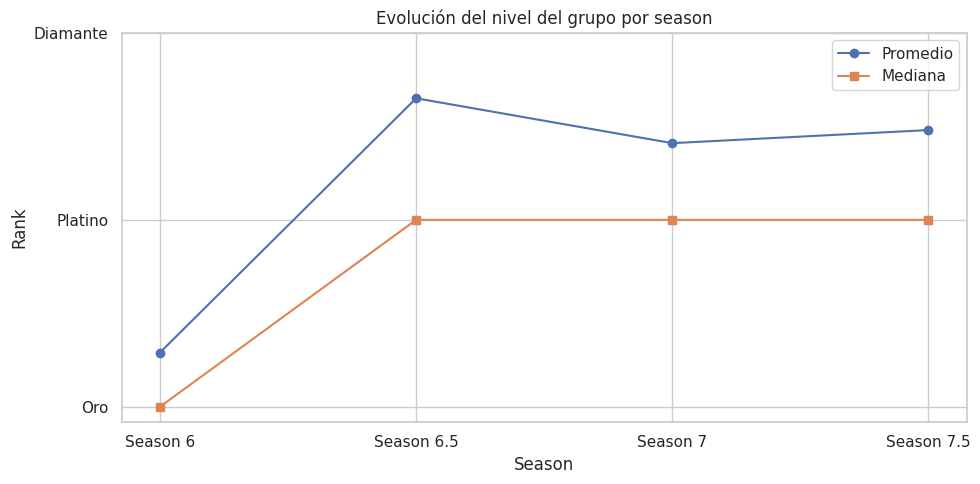

In [96]:
# 7.1 Promedio y mediana por corte
plot_avg_median_rank(cut_summary, rank_label_map)

Este gráfico de barras apiladas muestra la distribución de jugadores por rango por **season**, permitiendo visualizar los cambios en la composición competitiva del grupo a lo largo del tiempo.

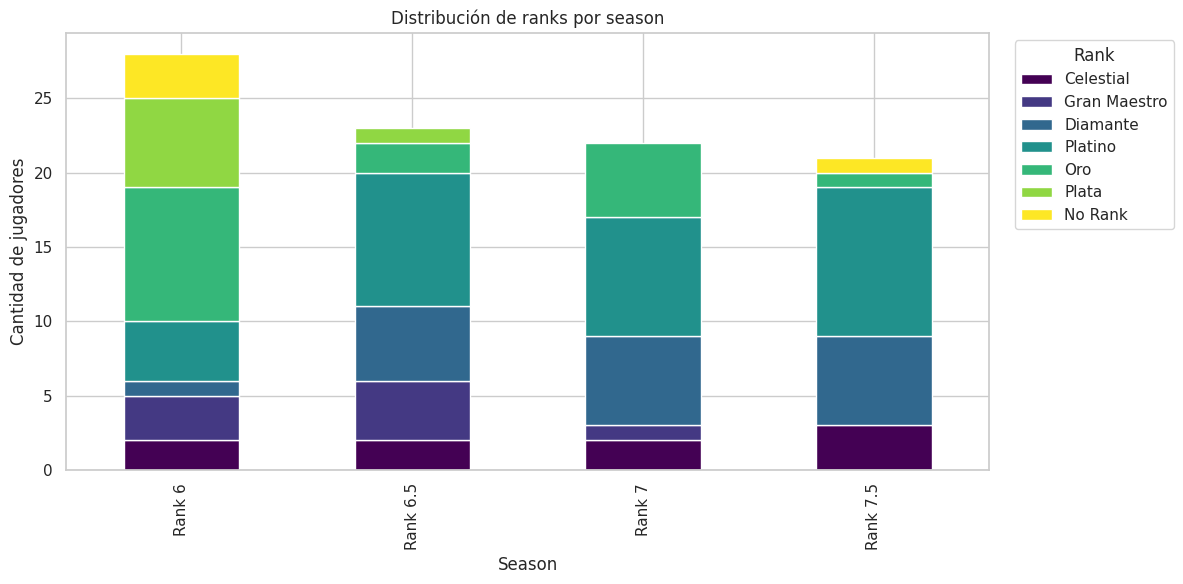

In [97]:
# 7.2 Distribución de ranks por corte
plot_rank_distribution(long_df, player_col, rank_label_map, rank_sequence_columns)

Este gráfico de barras compara el número de jugadores que mejoraron, se mantuvieron o empeoraron su rango entre cada par de **seasons** consecutivas, ofreciendo una visión clara de la dinámica de transición.

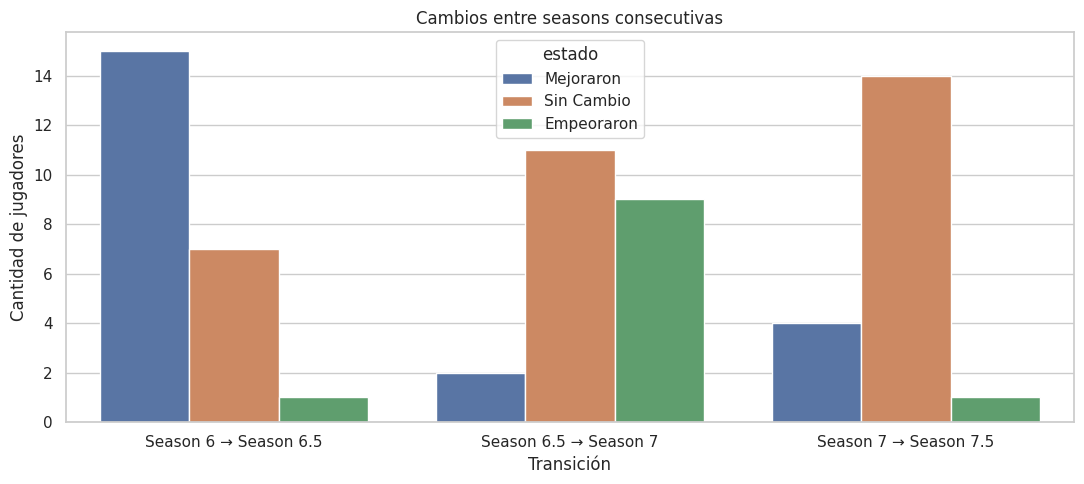

In [98]:
# 7.3 Mejoró / se mantuvo / empeoró por transición
plot_transitions(transitions_df)

Este gráfico visualiza las incorporaciones y salidas de jugadores del seguimiento en cada **season**, destacando la fluidez del grupo de análisis.

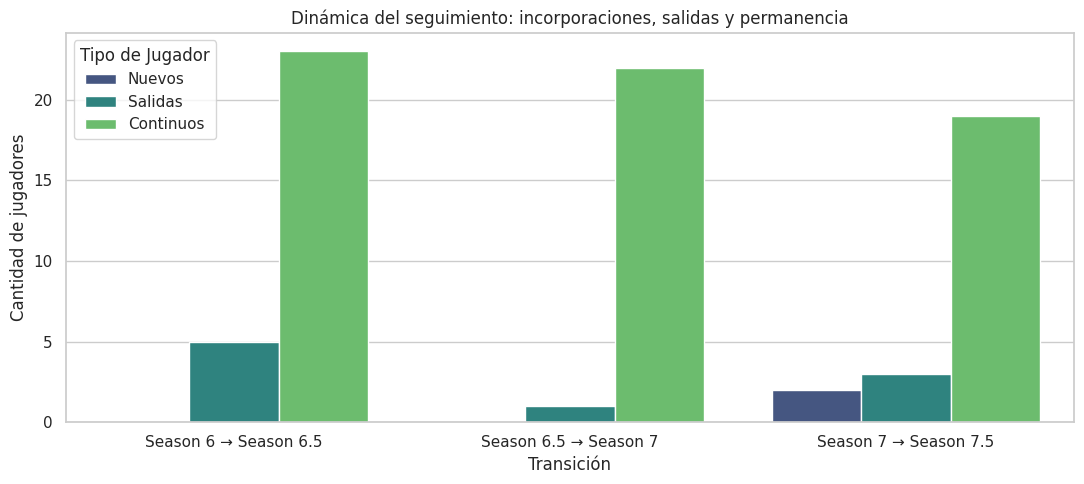

In [99]:
# 7.4 Incorporaciones y salidas
plot_entries_exits(entries_df)

Este 'slope chart' muestra la trayectoria individual de los rangos de los jugadores a lo largo de las **seasons**, permitiendo observar las tendencias de mejora o declive de cada uno.

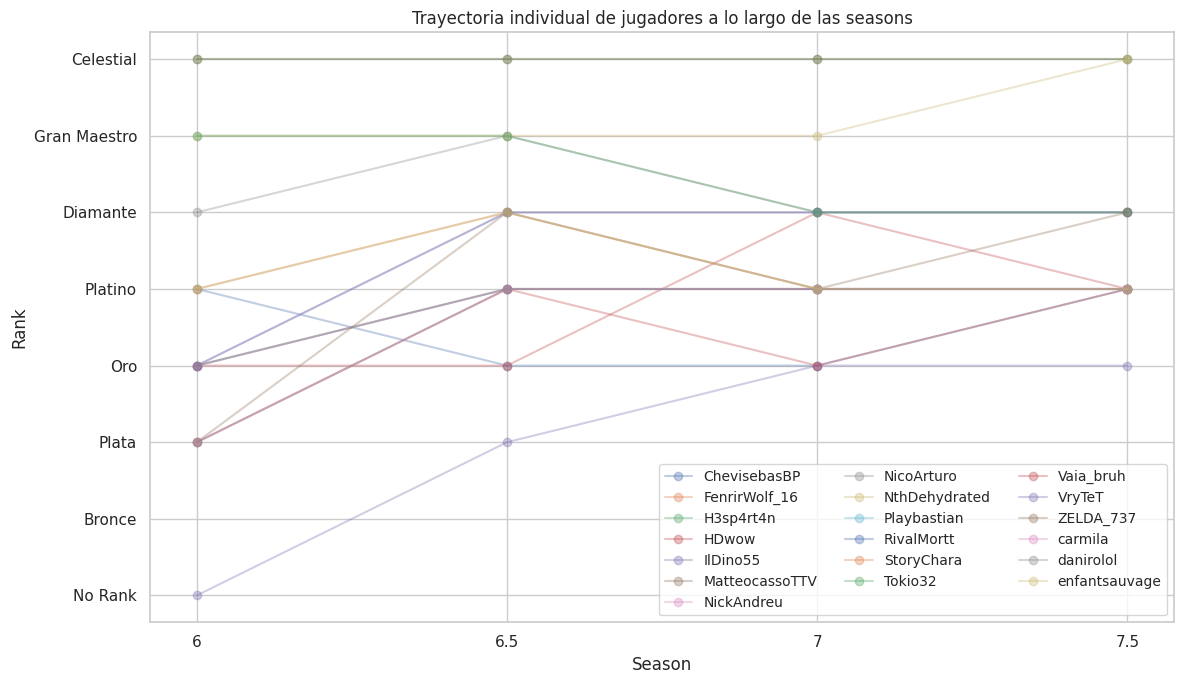

In [100]:
# 7.5 Slope chart simple para jugadores con al menos 2 cortes
plot_slope_chart(long_df, path_df, player_col, rank_label_map, last_season)

Finalmente, esta sección genera y muestra el resumen ejecutivo, que consolida todos los hallazgos clave del análisis en un formato conciso y fácil de leer.

In [101]:
# -------------------------
# 8) Resumen ejecutivo
# -------------------------
informe = executive_summary_md(cut_summary, transitions_df, entries_df)
display(Markdown(informe))


## Resumen ejecutivo

El seguimiento cubre desde **Season 6** hasta **Season 7.5**.

### Tendencia general

- El promedio del grupo **mejoró 1.19 tiers** entre **Season 6** y **Season 7.5**.
- El promedio del grupo pasó de **Oro - Platino** a **Platino - Diamante**.
- La mediana del grupo pasó de **Oro** a **Platino**.

### Composición competitiva exacta del grupo

- **Eternidad:** **0 → 0**
- **Celestial:** **2 → 3**
- **Gran Maestro:** **3 → 0**
- **Diamante:** **1 → 6**
- **Platino:** **4 → 10**
- **Oro:** **9 → 1**
- **Plata:** **6 → 0**
- **Bronce:** **0 → 0**
- **No Rank:** **3 → 1**

### Lectura agregada

- Jugadores en **Oro/Plata/Bronce**: **15 → 1**


### Cambios entre seasons consecutivas

- **Mejoras acumuladas:** 21
- **Mantenimientos acumulados:** 32
- **Retrocesos acumulados:** 11



### Dinámica del seguimiento

- **Incorporaciones al seguimiento:** 2
- **Salidas del seguimiento:** 9

> Los valores nulos en los ranks representan **ausencia en el seguimiento del grupo en esa season**, no ausencia de rango competitivo dentro del juego.

